# Use the logistic regression for Analysing Sensitivity and specificity and Plotting AUC-ROC curves

## Dataset - BreastCancer.csv

1. Split into training and testing sets (70:30)
2. Train Logistic Regression Classifier
3. Predict the probabilities along with the class labels.
4. Apply Threshold variation for thresholds = [0.1, 0.2, 0.3, ..., 0.9]. 
5. Compute Metrics- Confusion Matrix, Sensitivity and Specificity
6. Plot Analysis: Sensitivity vs Threshold


## EDA

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv("breast-cancer.csv")
data.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [3]:
data.columns

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='object')

In [4]:
np.round(data.describe(),3)


,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,5.690000e+02,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,...,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000
mean,3.037183e+07,14.127,19.290,91.969,654.889,0.096,0.104,0.089,0.049,0.181,...,16.269,25.677,107.261,880.583,0.132,0.254,0.272,0.115,0.290,0.084
std,1.250206e+08,3.524,4.301,24.299,351.914,0.014,0.053,0.080,0.039,0.027,...,4.833,6.146,33.603,569.357,0.023,0.157,0.209,0.066,0.062,0.018
min,8.670000e+03,6.981,9.710,43.790,143.500,0.053,0.019,0.000,0.000,0.106,...,7.930,12.020,50.410,185.200,0.071,0.027,0.000,0.000,0.156,0.055
25%,8.692180e+05,11.700,16.170,75.170,420.300,0.086,0.065,0.030,0.020,0.162,...,13.010,21.080,84.110,515.300,0.117,0.147,0.114,0.065,0.250,0.071
50%,9.060240e+05,13.370,18.840,86.240,551.100,0.096,0.093,0.062,0.034,0.179,...,14.970,25.410,97.660,686.500,0.131,0.212,0.227,0.100,0.282,0.080
75%,8.813129e+06,15.780,21.800,104.100,782.700,0.105,0.130,0.131,0.074,0.196,...,18.790,29.720,125.400,1084.000,0.146,0.339,0.383,0.161,0.318,0.092
max,9.113205e+08,28.110,39.280,188.500,2501.000,0.163,0.345,0.427,0.201,0.304,...,36.040,49.540,251.200,4254.000,0.223,1.058,1.252,0.291,0.664,0.208


## Data Preprocessing

In [5]:
# Droping ID from training data as it's useless

data = data.drop(columns=["id"])

# Droping diagnosis from training data as it's the target

data["diagnosis"] = data["diagnosis"].map({"M":1, "B":0})
X = data.drop(columns=["diagnosis"]).values
y = data["diagnosis"].values

print(X[0])
y[:5]


[1.799e+01 1.038e+01 1.228e+02 1.001e+03 1.184e-01 2.776e-01 3.001e-01
 1.471e-01 2.419e-01 7.871e-02 1.095e+00 9.053e-01 8.589e+00 1.534e+02
 6.399e-03 4.904e-02 5.373e-02 1.587e-02 3.003e-02 6.193e-03 2.538e+01
 1.733e+01 1.846e+02 2.019e+03 1.622e-01 6.656e-01 7.119e-01 2.654e-01
 4.601e-01 1.189e-01]


array([1, 1, 1, 1, 1])

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, 
                                                    y, 
                                                    random_state=37, 
                                                    test_size=0.3)

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

In [7]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)


(398, 30)
(398,)
(171, 30)
(171,)


### Logistic Regression

In [8]:
class LogisticRegression : 
    def __init__(self, lr = 0.01, epochs = 1000):
        self.lr = lr
        self.epochs = epochs 
        
    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))
    
    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.w = np.zeros(n_features)
        self.b = 0 
        
        for _ in range(self.epochs):
            linear = np.dot(X, self.w) + self.b
            y_pred = self.sigmoid(linear)
            
            dw = (1/n_samples) * np.dot(X.T, (y_pred - y))
            db = (1/n_samples) * np.sum(y_pred-y)
            
            self.w -= self.lr * dw 
            self.b -= self.lr * db 
            
    def predict_proba(self, X):
        linear = np.dot(X, self.w) + self.b
        return self.sigmoid(linear)
    
    def predict(self, X, threahold=0.5):
        probs = self.predict_proba(X)
        return (probs >= threahold).astype(int)
    

### Classification Metrics

In [9]:
def metrics(y_true, y_pred):
    TP = np.sum((y_true == 1) & (y_pred == 1))
    TN = np.sum((y_true == 0) & (y_pred == 0))
    FP = np.sum((y_true == 0) & (y_pred == 1))
    FN = np.sum((y_true == 1) & (y_pred == 0))
    return TP, TN, FP, FN

def sensitivity(TP, FN):
    return TP / (TP + FN + 1e-8)

def specificity(TN, FP):
    return TN / (TN + FP + 1e-8)


### Training and inference

In [10]:
model = LogisticRegression(lr=0.1,
                           epochs=1000)
model.fit(X_train, y_train)

In [11]:
probs = model.predict_proba(X_test)        
preds = model.predict(X_test, threahold=0.5)  

print("Sample Probabilities:", np.round(probs[:5]))
print("Sample Predictions  :", preds[:5])
print("Actual Labels       :", y_test[:5])

Sample Probabilities: [0. 0. 0. 0. 0.]
Sample Predictions  : [0 0 0 0 0]
Actual Labels       : [0 0 0 0 0]


In [12]:
thresholds = np.round(np.arange(0.1, 1.0, 0.1), 1)

results = []
for t in thresholds:
    y_pred = (probs >= t).astype(int)
    TP, TN, FP, FN = metrics(y_test, y_pred)
    sens = sensitivity(TP, FN)
    spec = specificity(TN, FP)
    results.append({
        "Threshold"  : t,
        "TP": TP, "TN": TN, "FP": FP, "FN": FN,
        "Sensitivity": round(sens, 4),
        "Specificity": round(spec, 4)
    })

df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))

 Threshold  TP  TN  FP  FN  Sensitivity  Specificity
       0.1  57 101  11   2       0.9661       0.9018
       0.2  57 107   5   2       0.9661       0.9554
       0.3  57 110   2   2       0.9661       0.9821
       0.4  56 111   1   3       0.9492       0.9911
       0.5  56 112   0   3       0.9492       1.0000
       0.6  54 112   0   5       0.9153       1.0000
       0.7  54 112   0   5       0.9153       1.0000
       0.8  54 112   0   5       0.9153       1.0000
       0.9  52 112   0   7       0.8814       1.0000


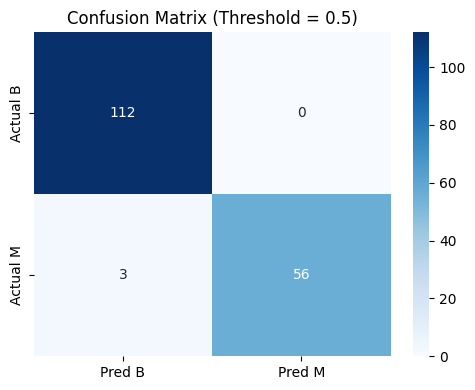

In [13]:
preds_05 = model.predict(X_test, threahold=0.5)
TP, TN, FP, FN = metrics(y_test, preds_05)

cm = np.array([[TN, FP],
               [FN, TP]])

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Pred B", "Pred M"],
            yticklabels=["Actual B", "Actual M"])
plt.title("Confusion Matrix (Threshold = 0.5)")
plt.tight_layout()
plt.show()

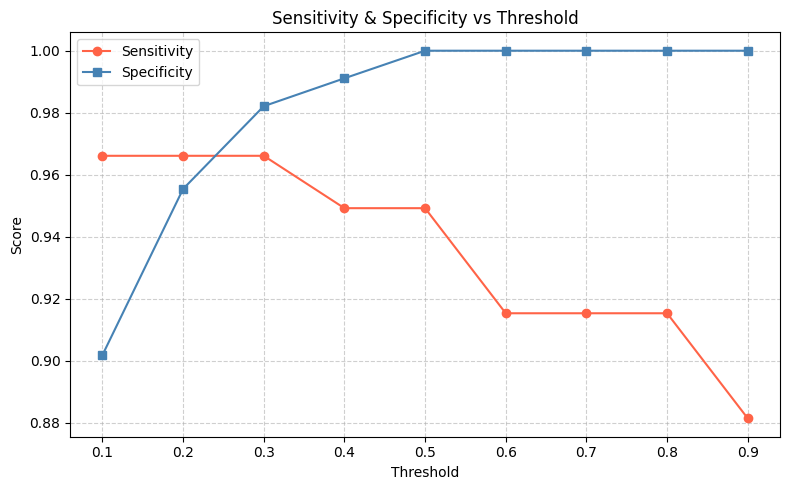

In [14]:
plt.figure(figsize=(8, 5))
plt.plot(df_results["Threshold"], df_results["Sensitivity"],
         marker="o", color="tomato",  label="Sensitivity")
plt.plot(df_results["Threshold"], df_results["Specificity"],
         marker="s", color="steelblue", label="Specificity")

plt.xticks(thresholds)
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Sensitivity & Specificity vs Threshold")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

Threshold: 0.1, Cost: 14
Threshold: 0.2, Cost: 8
Threshold: 0.3, Cost: 8
Threshold: 0.4, Cost: 3
Threshold: 0.5, Cost: 1
Threshold: 0.6, Cost: 2
Threshold: 0.7, Cost: 3
Threshold: 0.8, Cost: 8
Threshold: 0.9, Cost: 10
Best Threshold: 0.5


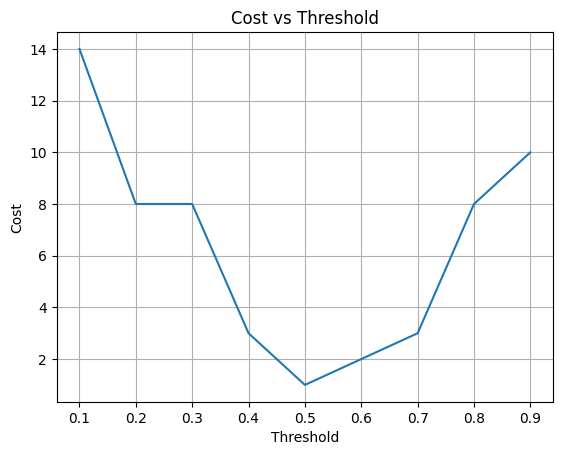

In [ ]:
cost_fn = 100 # the cost of missing cancer 
cost_fp = 1

costs = []

for t in thresholds:
    preds = (probs >= t).astype(int)
    
    TP, TN, FP, FN = metrics(y_test, preds)
    
    total_cost = FN * cost_fn + FP * cost_fp
    costs.append(total_cost)

    print(f"Threshold: {t:.1f}, Cost: {total_cost}")
    
best_idx = np.argmin(costs)
best_threshold = thresholds[best_idx]

print(f"Best Threshold: {best_threshold}")

plt.figure()
plt.plot(thresholds, costs)
plt.xlabel("Threshold")
plt.ylabel("Cost")
plt.title("Cost vs Threshold")
plt.grid()
plt.show()